# Slow Dynamics and High Variability in Networks with Clustered Connections

In [67]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt

from clustered_networks import ClusterParams, ModelParams, NeuronNetwork
from clustered_networks.plotting import (
    plot_spike_raster, plot_trial_rasters, plot_rasters_from_spike_data,
    plot_firing_rate_distribution, plot_fano_factor,
    plot_fano_vs_window, plot_fano_vs_ree,
    plot_correlation_all_pairs, plot_correlation_same_cluster,
    plot_correlation_tail,
    plot_covariance_comparison, plot_high_corr_pair_rasters,
    plot_stim_raster, save_all_figures,
)
from clustered_networks.experiment import Experiment, load_spike_data_from_disk
from clustered_networks.analysis import (
    compute_fano_factor_for_ree,
    compute_covariance_uniform_vs_clustered_from_spike_data,
)

# Run and plot an un-clustered network

In [68]:
params = ModelParams()
cluster_params = ClusterParams(enabled=False, R_ee=1.0)

unclustered_network = NeuronNetwork(params, cluster_params)
unclustered_network.run()

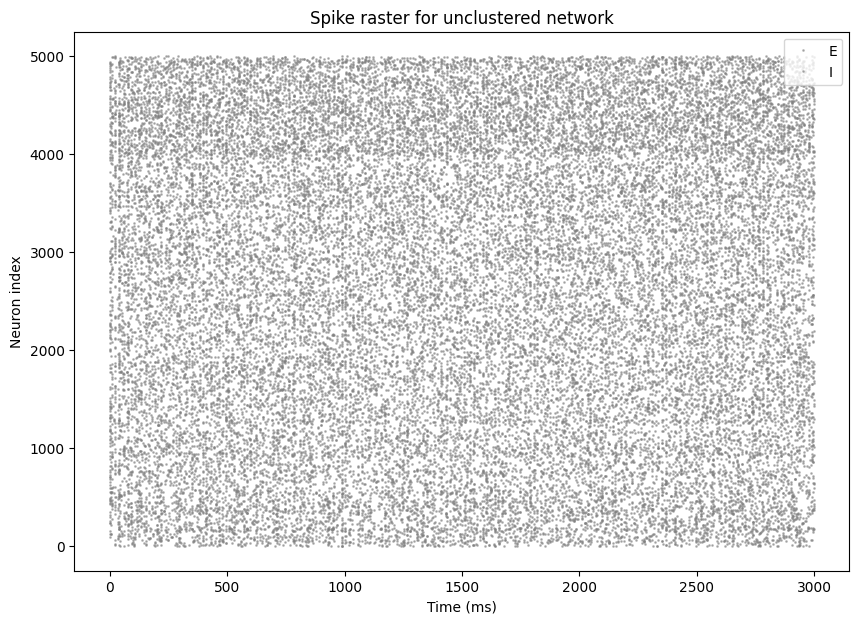

In [69]:
plot_spike_raster(
    unclustered_network.spike_monitor_e,
    unclustered_network.spike_monitor_i,
    n_e=params.N_E,
    title="Spike raster for unclustered network",
)
plt.show()

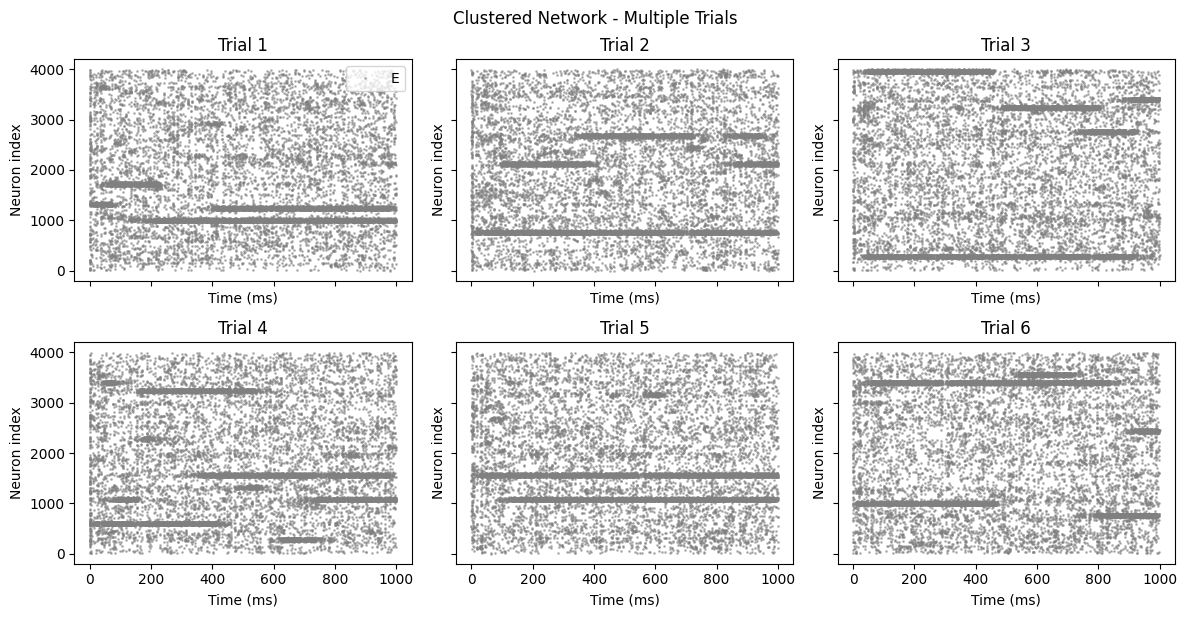

In [70]:
trial_network = NeuronNetwork(
    ModelParams(duration=1*second),
    ClusterParams(enabled=True, R_ee=2.5),
    seed=123,
)
fig, axes = plot_trial_rasters(trial_network, n_trials=6, ncols=3, show_inhibitory=False)
fig.suptitle("Clustered Network - Multiple Trials", y=1.02)
plt.show()

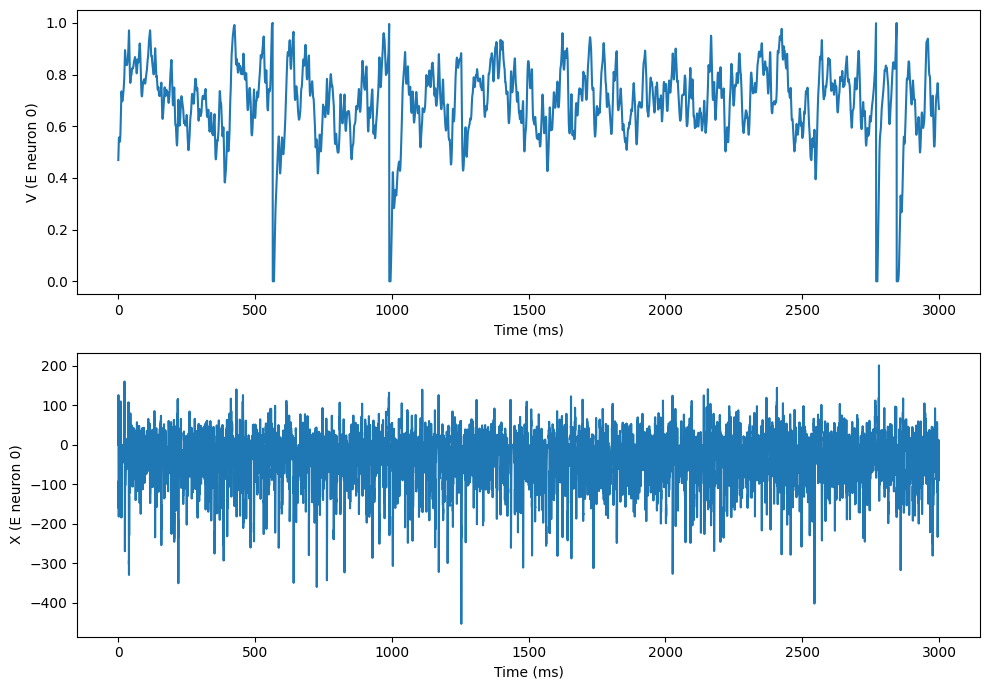

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))
axes[0].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')
axes[1].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')
plt.tight_layout()

# Run and plot a clustered network

In [72]:
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=2.5)

clustered_network = NeuronNetwork(params, cluster_params)
clustered_network.run()

<Axes: title={'center': 'Spike raster'}, xlabel='Time (ms)', ylabel='Neuron index'>

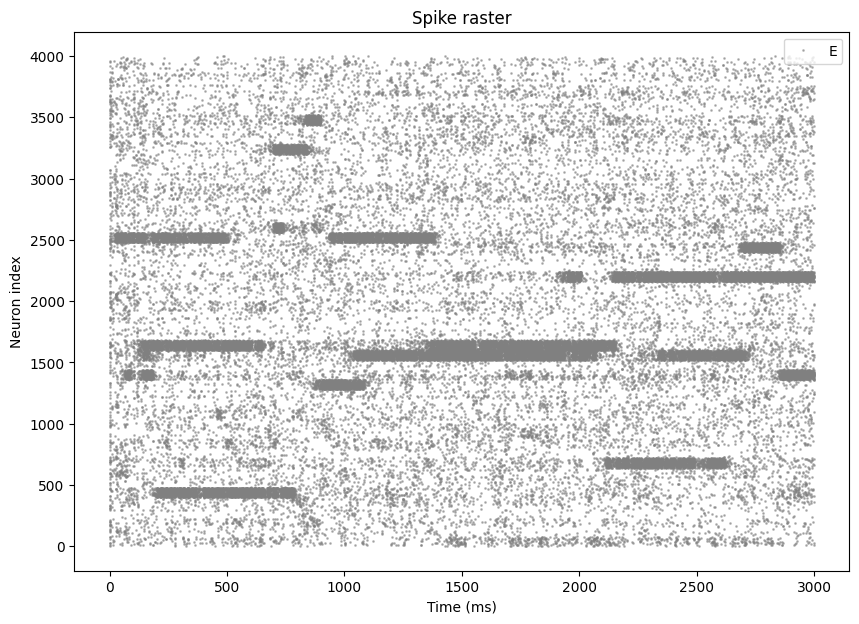

In [73]:
plot_spike_raster(clustered_network.spike_monitor_e)

## Plot the membrane potentials of a few neurons

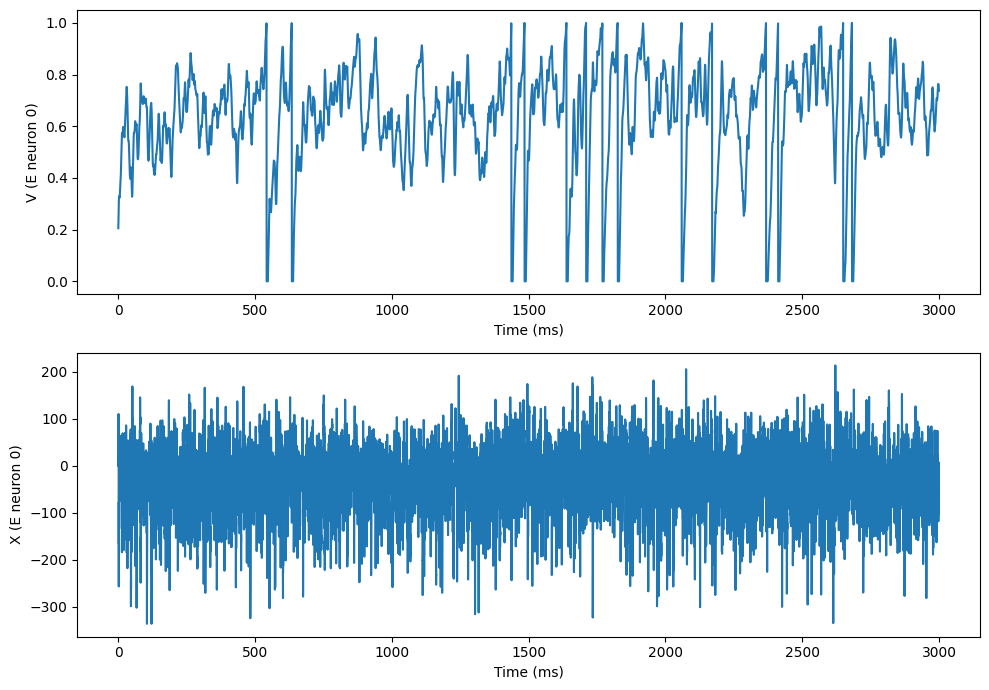

In [74]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))
axes[0].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')
axes[1].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()

# Experiment

Now instead of looking at a single network, we follow the paper's protocol of testing the uniform and clustered networks across 12 different network realizations, with 9 trials for each realization. This enables statistical analysis on spike counts.

## Metrics

**Firing Rate**: Spikes per neuron divided by the analysis window duration (Hz).

**Fano Factor**: Variance-to-mean ratio of spike counts across trials. A Poisson process has FF=1; values >1 indicate higher variability (bursty firing).

**Correlation Coefficient**: Spikes are binned into sliding time windows to create a spike count time series per neuron. We overlap the sliding time windows. The correlation coefficient between neuron pairs is: $\rho_{ij} = \text{Cov}(X_i, X_j) / (\sigma_i \sigma_j)$.

In [75]:
# Run experiment (or load from disk below)
experiment = Experiment(
    realizations=3,
    trials=9,
    model_params=ModelParams(duration=3*second),
    cluster_params=ClusterParams(enabled=True, R_ee=2.5),
)
spike_data = experiment.run()

Built uniform network 1/3
Built uniform network 2/3
Built uniform network 3/3
Built clustered network 1/3
Built clustered network 2/3
Built clustered network 3/3
Running uniform networks...
  Realization 1/3, Trial 1/9
  Realization 1/3, Trial 2/9
  Realization 1/3, Trial 3/9
  Realization 1/3, Trial 4/9
  Realization 1/3, Trial 5/9
  Realization 1/3, Trial 6/9
  Realization 1/3, Trial 7/9
  Realization 1/3, Trial 8/9
  Realization 1/3, Trial 9/9
  Realization 2/3, Trial 1/9
  Realization 2/3, Trial 2/9
  Realization 2/3, Trial 3/9
  Realization 2/3, Trial 4/9
  Realization 2/3, Trial 5/9
  Realization 2/3, Trial 6/9
  Realization 2/3, Trial 7/9
  Realization 2/3, Trial 8/9
  Realization 2/3, Trial 9/9
  Realization 3/3, Trial 1/9
  Realization 3/3, Trial 2/9
  Realization 3/3, Trial 3/9
  Realization 3/3, Trial 4/9
  Realization 3/3, Trial 5/9
  Realization 3/3, Trial 6/9
  Realization 3/3, Trial 7/9
  Realization 3/3, Trial 8/9
  Realization 3/3, Trial 9/9
Running clustered networks.

In [76]:
# Alternative: load spike_data from disk
# spike_data, loaded_run_path = load_spike_data_from_disk()

Mean Fano Factor (Uniform): 0.854
Mean Fano Factor (Clustered): 1.835


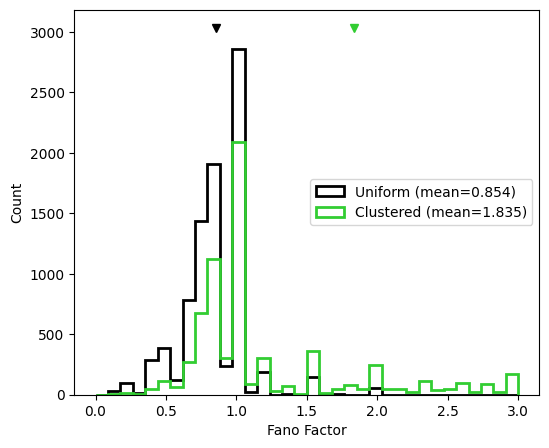

In [77]:
plot_fano_factor(spike_data)
plt.show()

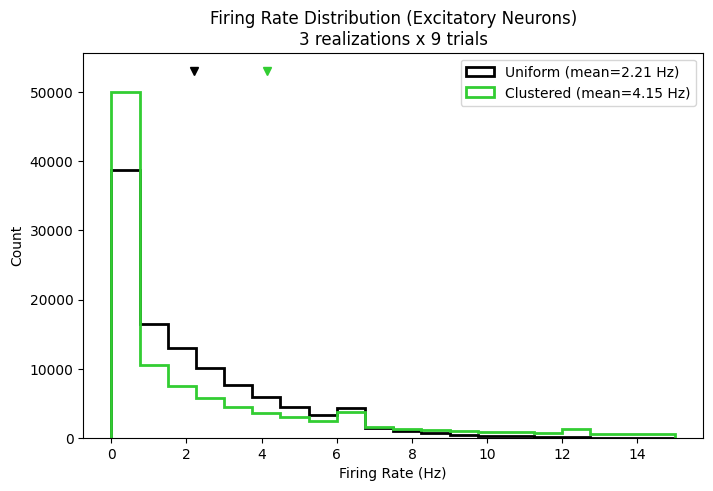

In [78]:
plot_firing_rate_distribution(spike_data)
plt.show()

Window 50ms (all pairs):
  Uniform: 0.0005, Clustered: 0.0013
Window 100ms (all pairs):
  Uniform: 0.0003, Clustered: 0.0016


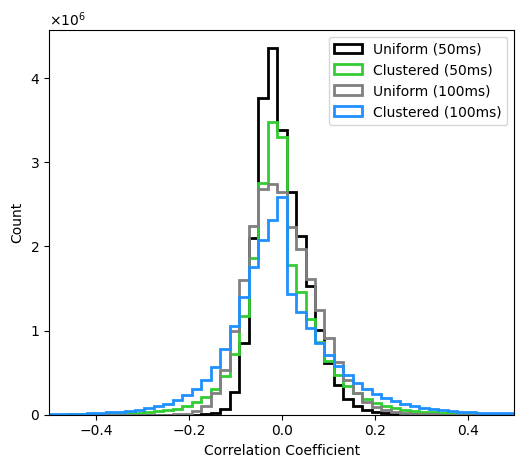

Window 50ms (same cluster):
  Uniform: 0.0005, Clustered: 0.3194
Window 100ms (same cluster):
  Uniform: 0.0004, Clustered: 0.3694


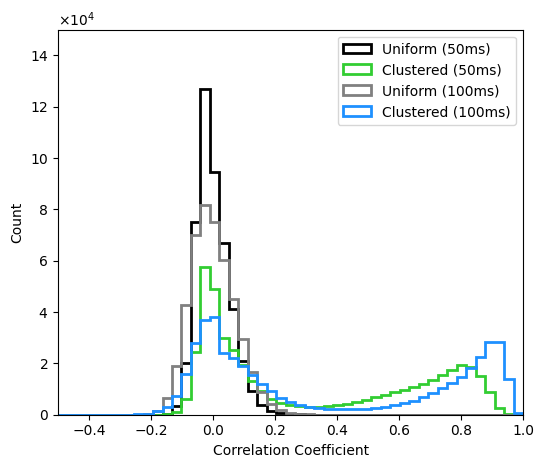

In [79]:
plot_correlation_all_pairs(spike_data)
plt.show()

plot_correlation_same_cluster(spike_data)
plt.show()

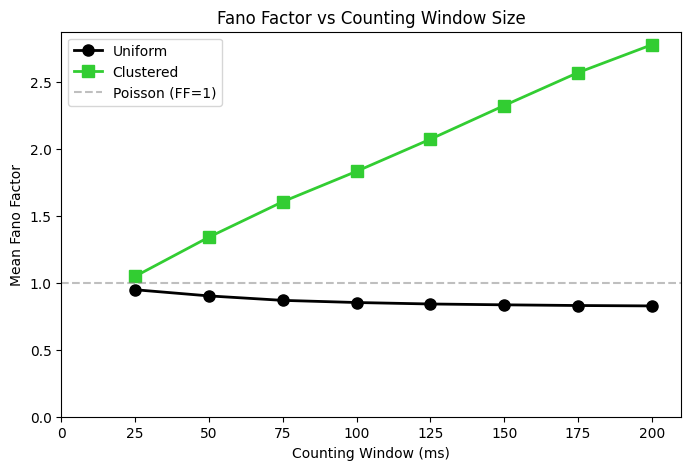

In [80]:
plot_fano_vs_window(spike_data)
plt.show()

## Stimulus Experiment

In [81]:
N_E = 4000
multipliers_2 = np.full((60), 2)
multipliers_1 = np.ones((N_E - 60))
multipliers = np.hstack((multipliers_2, multipliers_1))
stimulus_time = (1.5*second, 2.5*second)
params = ModelParams(stimulus_multipliers=multipliers, stimulus_time=stimulus_time)

In [82]:
cluster_params = ClusterParams(enabled=True, R_ee=2.5)
clustered_network = NeuronNetwork(params, cluster_params)
clustered_network.run()

In [83]:
cluster_params = ClusterParams(enabled=False, R_ee=1.0)
unclustered_network = NeuronNetwork(params, cluster_params)
unclustered_network.run()

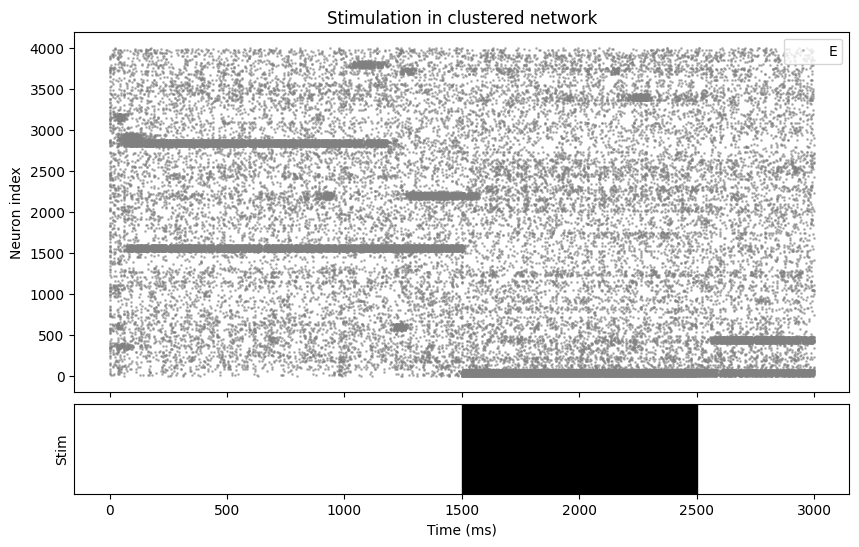

In [84]:
axes = plot_stim_raster(stimulus_time)
plot_spike_raster(
    clustered_network.spike_monitor_e,
    n_e=params.N_E,
    title="Stimulation in clustered network",
    ax=axes[0],
)
plt.show()

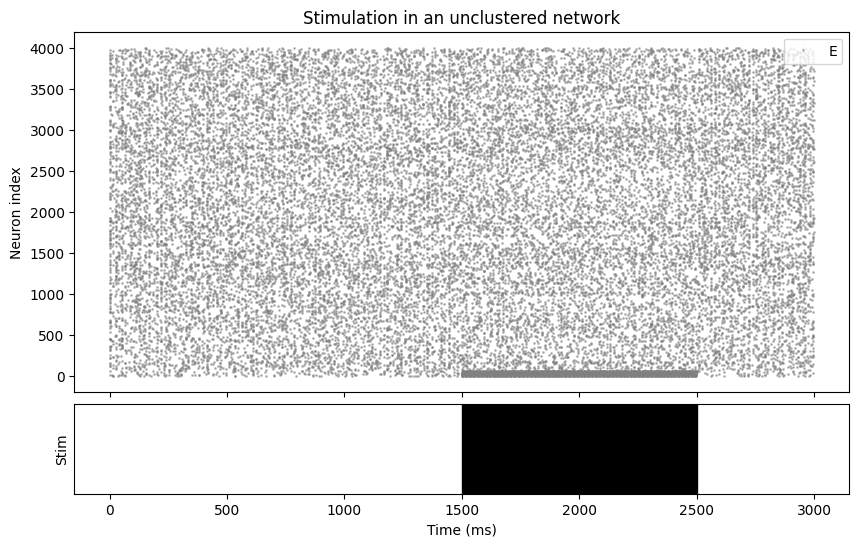

In [85]:
axes = plot_stim_raster(stimulus_time)
plot_spike_raster(
    unclustered_network.spike_monitor_e,
    n_e=params.N_E,
    title="Stimulation in an unclustered network",
    ax=axes[0],
)
plt.show()

# Comparing Fano Factor

In [86]:
R_ee_values = np.arange(1.0, 4.25, 0.25)
mean_fano_factors = compute_fano_factor_for_ree(R_ee_values, n_trials=9)

Running R_ee = 1.0...
  Mean Fano Factor: 0.834
Running R_ee = 1.25...
  Mean Fano Factor: 0.824
Running R_ee = 1.5...
  Mean Fano Factor: 0.831
Running R_ee = 1.75...
  Mean Fano Factor: 0.824
Running R_ee = 2.0...
  Mean Fano Factor: 0.846
Running R_ee = 2.25...
  Mean Fano Factor: 1.026
Running R_ee = 2.5...
  Mean Fano Factor: 1.828
Running R_ee = 2.75...
  Mean Fano Factor: 3.084
Running R_ee = 3.0...
  Mean Fano Factor: 4.317
Running R_ee = 3.25...
  Mean Fano Factor: 5.384
Running R_ee = 3.5...
  Mean Fano Factor: 5.896
Running R_ee = 3.75...
  Mean Fano Factor: 7.272
Running R_ee = 4.0...
  Mean Fano Factor: 7.546


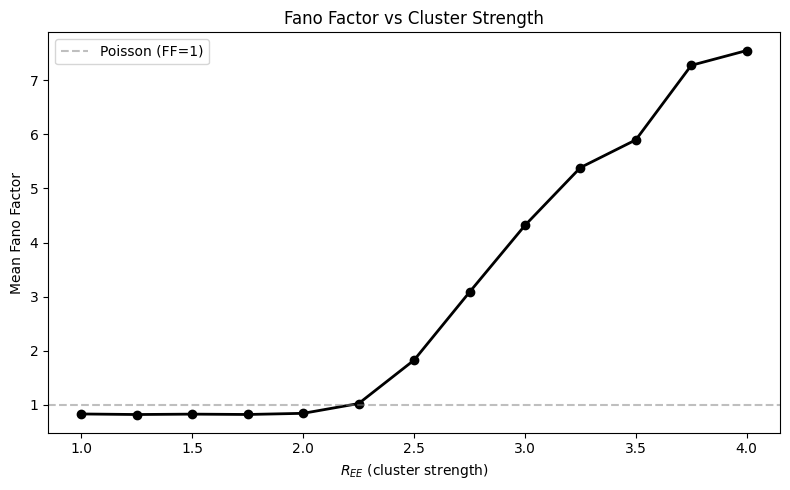

In [87]:
plot_fano_vs_ree(R_ee_values, mean_fano_factors)
plt.show()

# Autocovariance and Cross Covariance

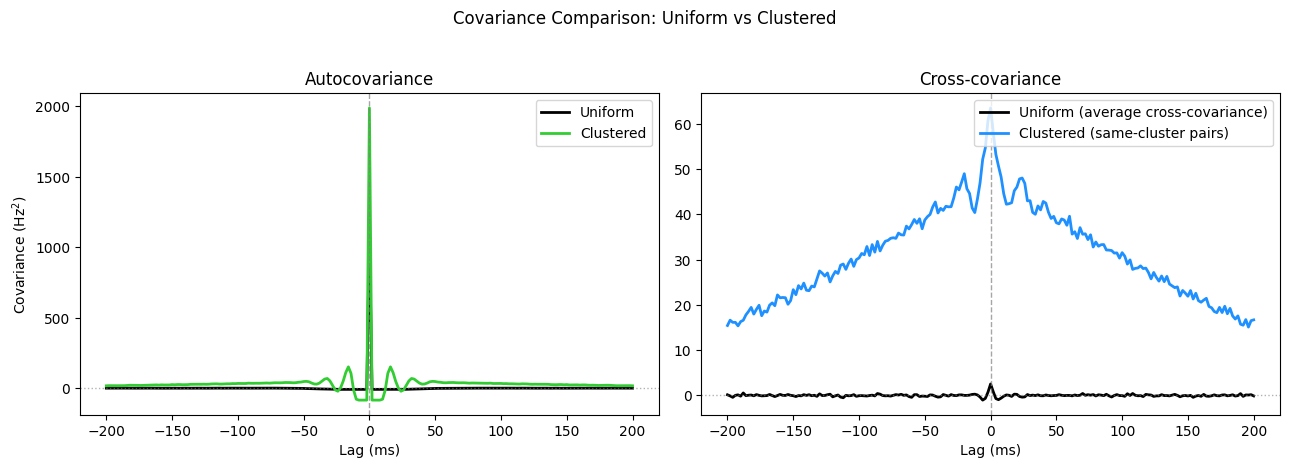

In [88]:
lags_ms, uniform_auto, uniform_cross, clustered_auto, clustered_cross = (
    compute_covariance_uniform_vs_clustered_from_spike_data(
        spike_data,
        bin_size_ms=2,
        max_lag_ms=200,
        max_pairs=2000,
        seed=0,
        normalize_by_mean_rate=False,
        clustered_within_cluster_pairs=True,
    )
)

fig, axes = plot_covariance_comparison(
    lags_ms, uniform_auto, clustered_auto, uniform_cross, clustered_cross,
    normalize_by_mean_rate=False,
)
plt.show()

In [89]:
save_all_figures(
    spike_data, R_ee_values, mean_fano_factors,
    output_dir="report/figures", dpi=300, format="pdf",
)

Saving firing rate distribution...
Saving fano factor distribution...
Mean Fano Factor (Uniform): 0.854
Mean Fano Factor (Clustered): 1.835
Saving correlation all pairs...
Window 50ms (all pairs):
  Uniform: 0.0005, Clustered: 0.0013
Window 100ms (all pairs):
  Uniform: 0.0003, Clustered: 0.0016
Saving correlation same cluster...
Window 50ms (same cluster):
  Uniform: 0.0005, Clustered: 0.3194
Window 100ms (same cluster):
  Uniform: 0.0004, Clustered: 0.3694
Saving fano factor vs window...
Saving fano factor vs ree...
Saving rasters uniform...
Saving rasters clustered...

Saved 8 figures to 'report/figures/':
  - firing_rate_distribution.pdf
  - fano_factor_distribution.pdf
  - correlation_all_pairs.pdf
  - correlation_same_cluster.pdf
  - fano_factor_vs_window.pdf
  - fano_factor_vs_ree.pdf
  - rasters_uniform.pdf
  - rasters_clustered.pdf


[PosixPath('report/figures/firing_rate_distribution.pdf'),
 PosixPath('report/figures/fano_factor_distribution.pdf'),
 PosixPath('report/figures/correlation_all_pairs.pdf'),
 PosixPath('report/figures/correlation_same_cluster.pdf'),
 PosixPath('report/figures/fano_factor_vs_window.pdf'),
 PosixPath('report/figures/fano_factor_vs_ree.pdf'),
 PosixPath('report/figures/rasters_uniform.pdf'),
 PosixPath('report/figures/rasters_clustered.pdf')]

## Correlation Tail Diagnostics (Simple and Direct)

These cells explain why the correlation histogram has a long right tail in clustered networks.

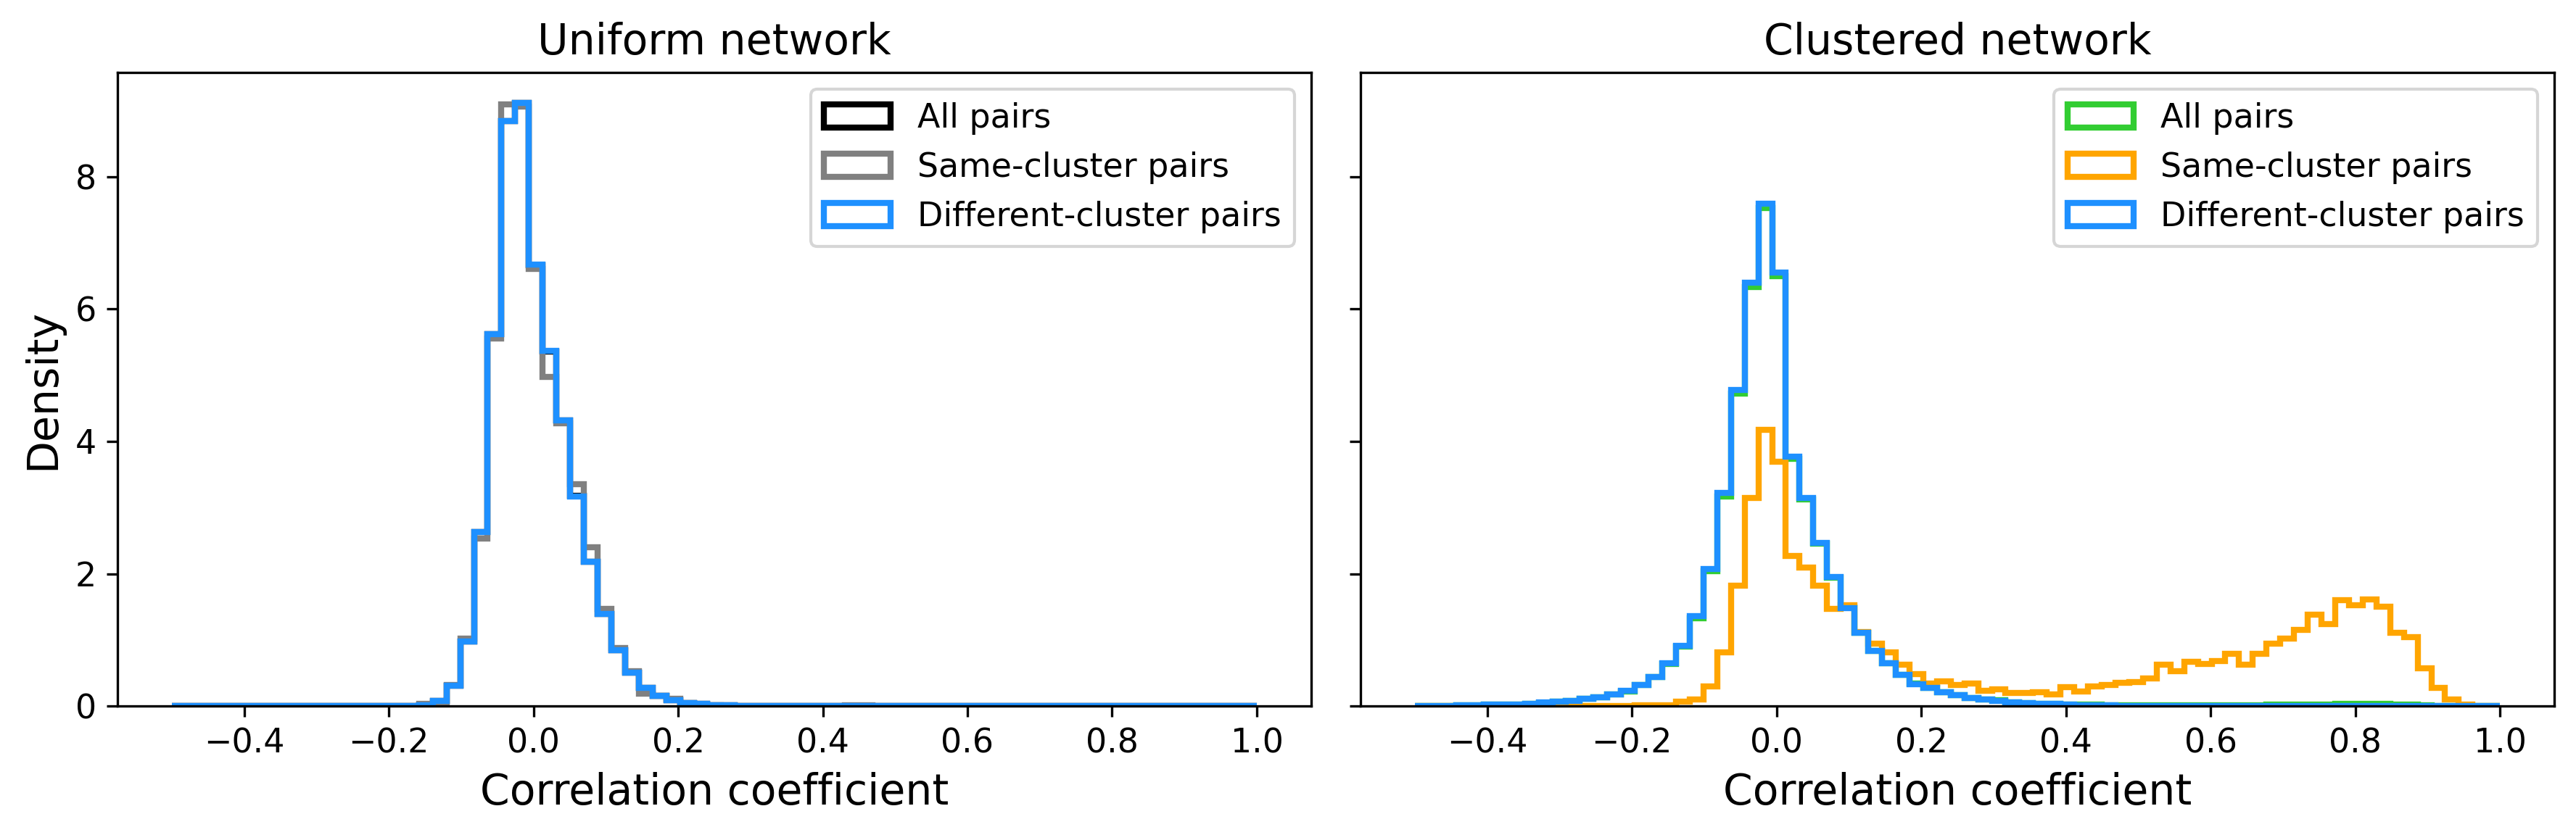


Summary (mean, q95, q99, p[r>0.2]):
Uniform   all  |  0.0004,  0.098,  0.153,  0.003
Uniform   same |  0.0005,  0.097,  0.146,  0.002
Uniform   diff |  0.0004,  0.098,  0.153,  0.003
Clustered all  |  0.0011,  0.160,  0.395,  0.033
Clustered same |  0.3369,  0.856,  0.901,  0.483
Clustered diff | -0.0056,  0.146,  0.263,  0.024

Same-cluster pair opportunities in full network: 158,000/7,998,000 (1.98%)

Tail composition in clustered network:
  r > 0.2: same-cluster share = 29.1% (3,301/11,337)
  r > 0.3: same-cluster share = 59.2% (3,082/5,209)
  r > 0.4: same-cluster share = 85.5% (2,934/3,431)
  r > 0.5: same-cluster share = 96.4% (2,730/2,831)


In [90]:
tail_subset_neurons = plot_correlation_tail(spike_data, subset_size=500, seed=0)

Found 46657 trial-active pairs above threshold r >= 0.50; plotting 6 sampled pairs.
Filtered out 52086 pairs because at least one neuron had 0 spikes in plotted trial window.
Note: displayed r is realization-level (averaged across all trials in this realization).
A pair can have high realization-level r even if spikes are sparse/non-overlapping in the plotted trial.


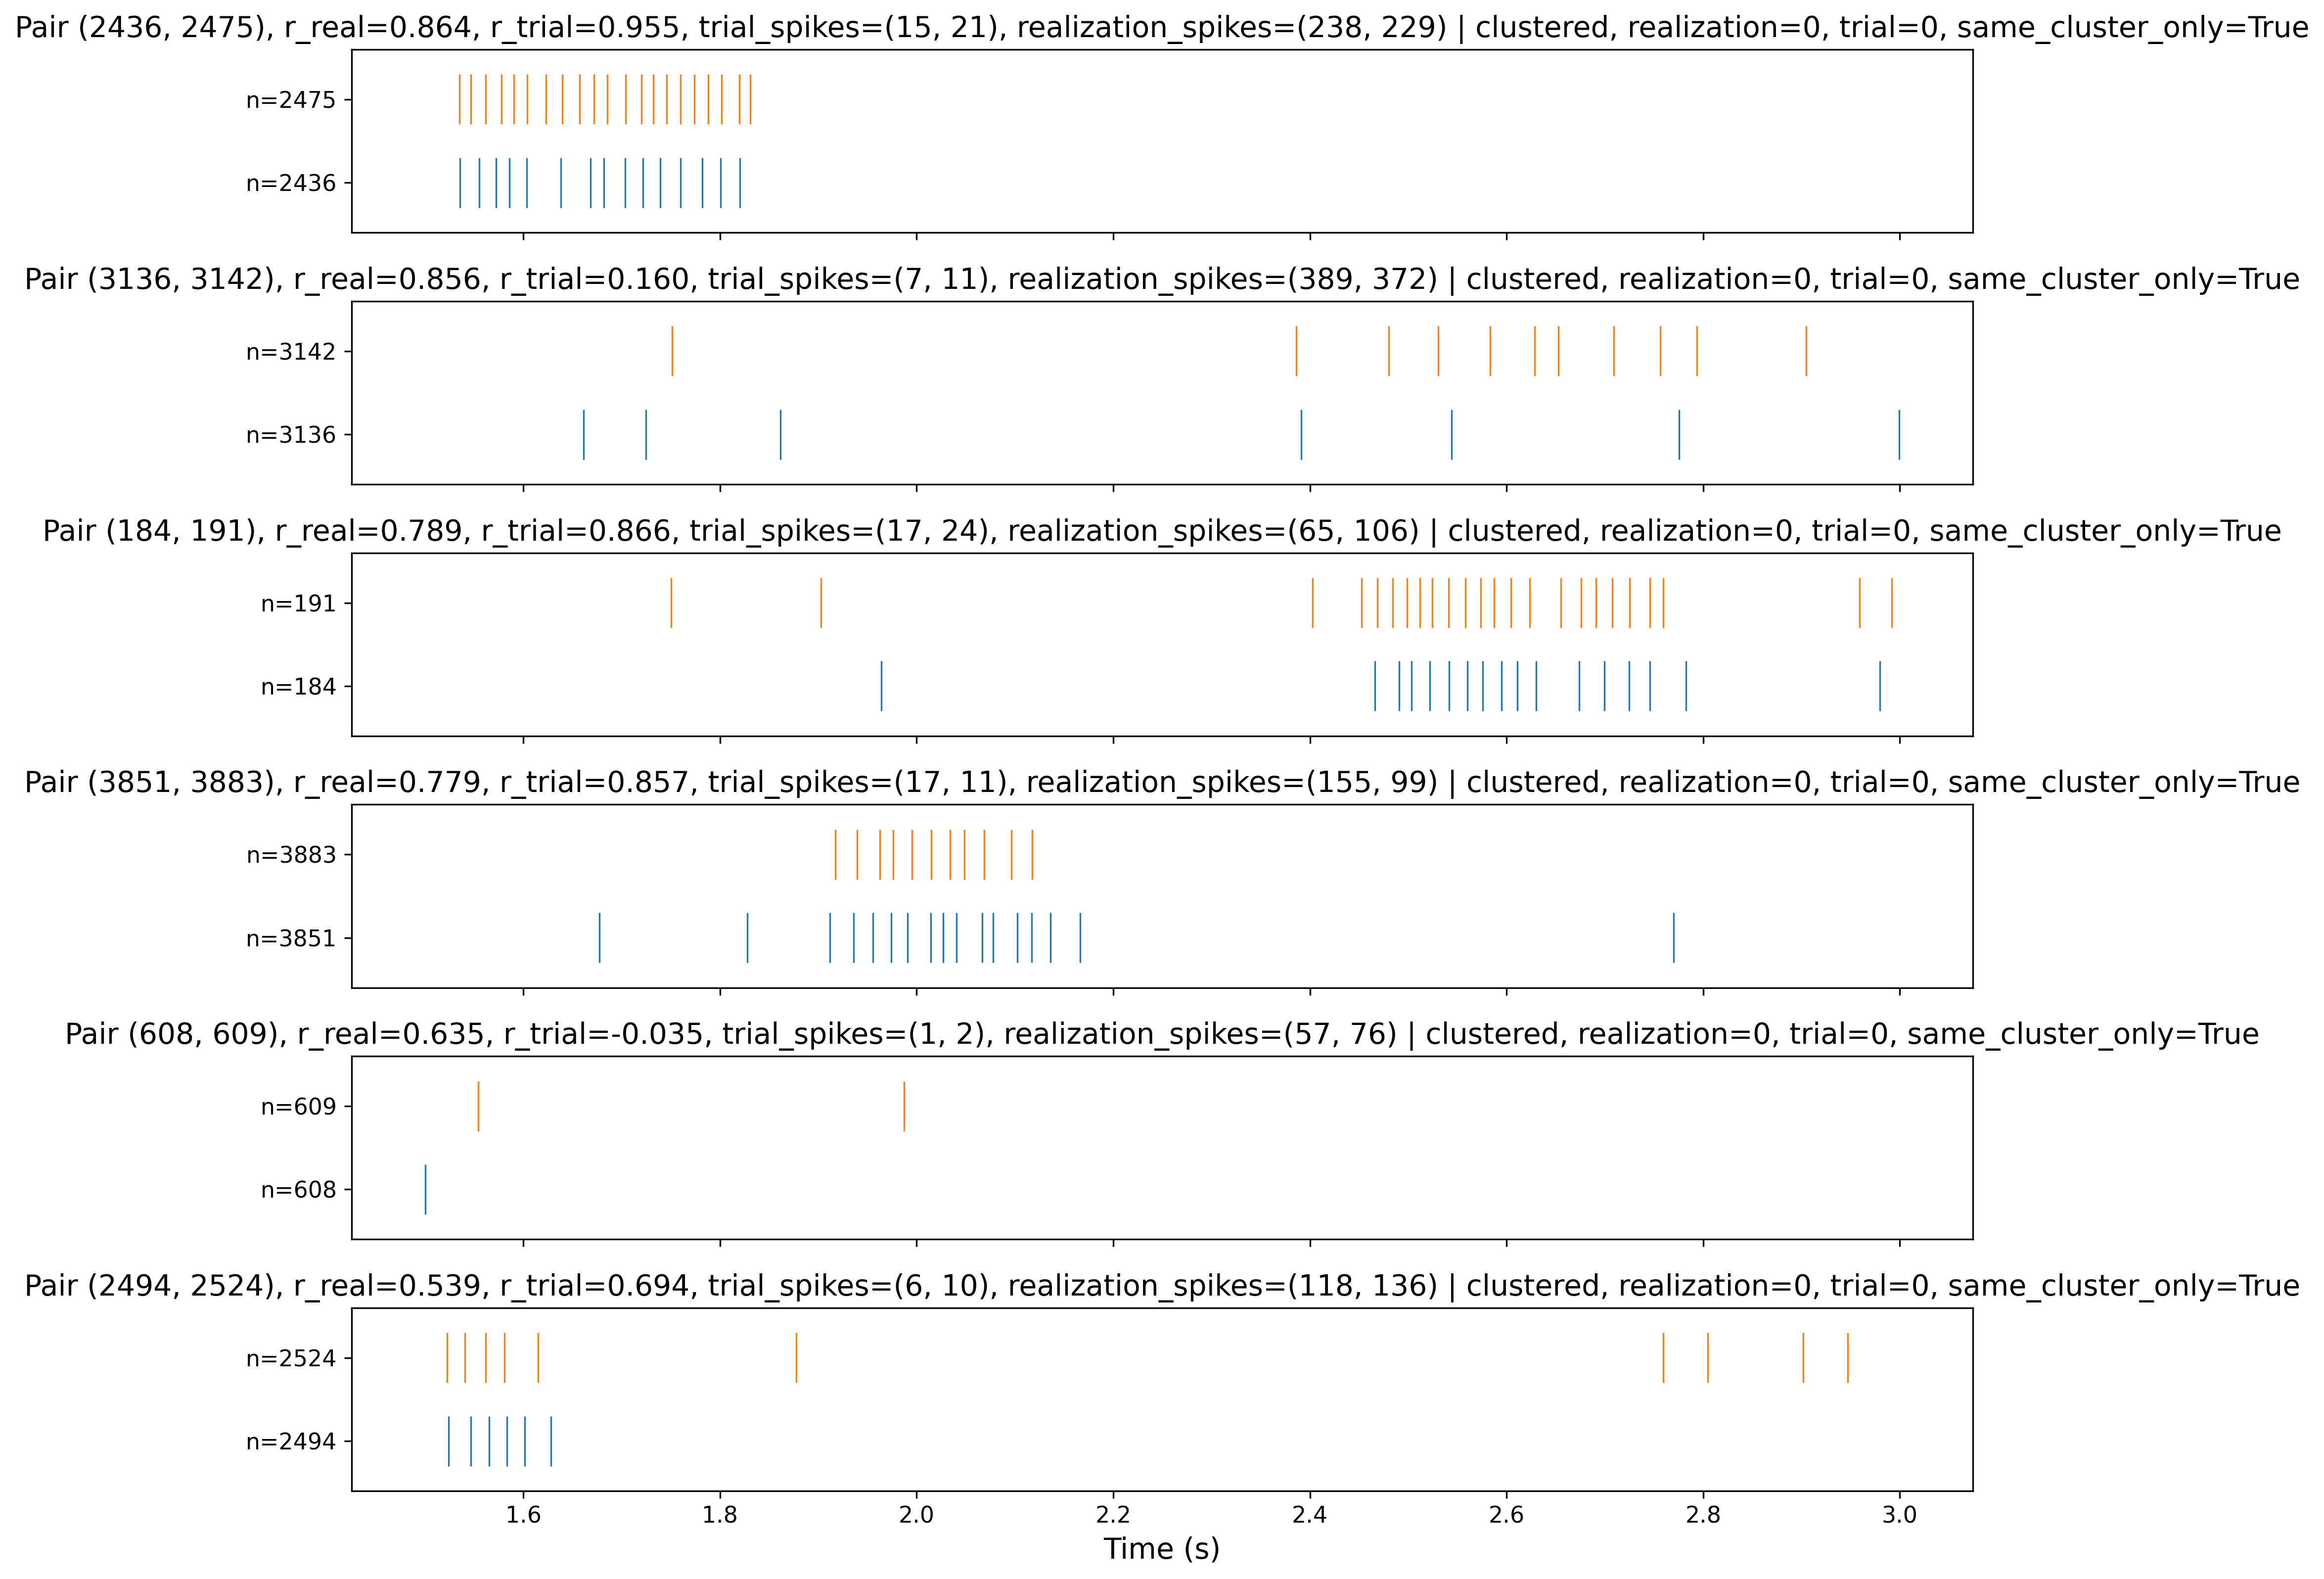

In [91]:
chosen_pairs, coeffs, pair_index_arrays = plot_high_corr_pair_rasters(
    spike_data,
    network_type="clustered",
    realization=0,
    trial=0,
    same_cluster_only=True,
    n_pairs=6,
    threshold=0.5,
)